In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

sys.path.append("/home/jovyan/base_demo")
import base_tool
print("✓ base_tool loaded")

✓ base_tool loaded


In [5]:
def get_trade_dates():
    trade_dates = [
        "20251201",
        "20251202",
        "20251203",
        "20251204",
        "20251205",
        "20251208",
        "20251209",
        "20251210",
        "20251211",
        "20251212",
        "20251215",
        "20251216",
        "20251217",
        "20251218",
        "20251219",
        "20251222",
        "20251223",
        "20251224",
        "20251225",
        "20251226",
        "20251229",
        "20251230",
        "20251231",
        "20260105",
        "20260106",
        "20260107",
        "20260108",
        "20260109",
        "20260112",
        "20260113",
        "20260114",
        "20260115",
        "20260116",
        "20260119",
        "20260120",
        "20260121",
        "20260122",
        "20260123",
        "20260126",
        "20260127",
        "20260128",
        "20260129",
        "20260130",
        "20260202",
        "20260203",
        "20260204",
        "20260205",
        "20260206",
        "20260209",
        "20260210",
        "20260211",
        "20260212",
        "20260213",
        "20260224",
        "20260225",
        "20260226",
        "20260227",

    ]
    return trade_dates

In [6]:
TRADING_DATES = get_trade_dates()

INSTRUMENTS = ["518880"]
MAX_SNAPS = 1000

In [7]:
def load_volatility_data(instrument, dates, max_snaps=1000):
    data = []
    for date_str in dates:
        try:
            snap_list = base_tool.snap_list_load(instrument, date_str)
            if snap_list and isinstance(snap_list, list):
                prices = [s.get("price_last", 0.0) for s in snap_list[:max_snaps] if s.get("price_last", 0) > 0]
                if len(prices) > 100:
                    prices_arr = np.array(prices)
                    data.append({
                        "date": date_str,
                        "datetime": pd.to_datetime(date_str, format="%Y%m%d"),
                        "instrument": instrument,
                        "open": float(prices_arr[0]),
                        "close": float(prices_arr[-1]),
                        "high": float(np.max(prices_arr)),
                        "low": float(np.min(prices_arr)),
                        "range": float(np.max(prices_arr) - np.min(prices_arr)),
                        "range_pct": float((np.max(prices_arr) - np.min(prices_arr)) / np.mean(prices_arr) * 100),
                        "std": float(np.std(prices_arr)),
                        "obs": len(prices),
                    })
        except Exception as e:
            print(f"{date_str}: {str(e)[:30]}")
    return pd.DataFrame(data) if data else None

all_dfs = {}
for inst in INSTRUMENTS:
    df = load_volatility_data(inst, TRADING_DATES, MAX_SNAPS)
    if df is not None:
        all_dfs[inst] = df
        print(f"{inst}: {len(df)} days loaded")

518880: 57 days loaded


In [8]:
df = all_dfs["518880"]
print("518880 Volatility Analysis")
print("=" * 50)
print(df[["date", "range_pct", "range"]].to_string(index=False))

518880 Volatility Analysis
    date  range_pct  range
20251201   0.349014  0.032
20251202   0.219165  0.020
20251203   0.164482  0.015
20251204   0.197408  0.018
20251205   0.110011  0.010
20251208   0.164874  0.015
20251209   0.121174  0.011
20251210   0.153688  0.014
20251211   0.131106  0.012
20251212   0.184832  0.017
20251215   0.225646  0.021
20251216   0.247523  0.023
20251217   0.268786  0.025
20251218   0.118177  0.011
20251219   0.215345  0.020
20251222   0.414994  0.039
20251223   0.403662  0.039
20251224   0.123525  0.012
20251225   0.104458  0.010
20251226   0.383201  0.037
20251229   0.249321  0.024
20251230   0.666219  0.062
20251231   0.373461  0.035
20260105   0.465985  0.044
20260106   0.209663  0.020
20260107   0.386271  0.037
20260108   0.178005  0.017
20260109   0.251240  0.024
20260112   0.255696  0.025
20260113   0.245297  0.024
20260114   0.101281  0.010
20260115   0.375670  0.037
20260116   0.182697  0.018
20260119   0.140416  0.014
20260120   0.109946  0.011
2

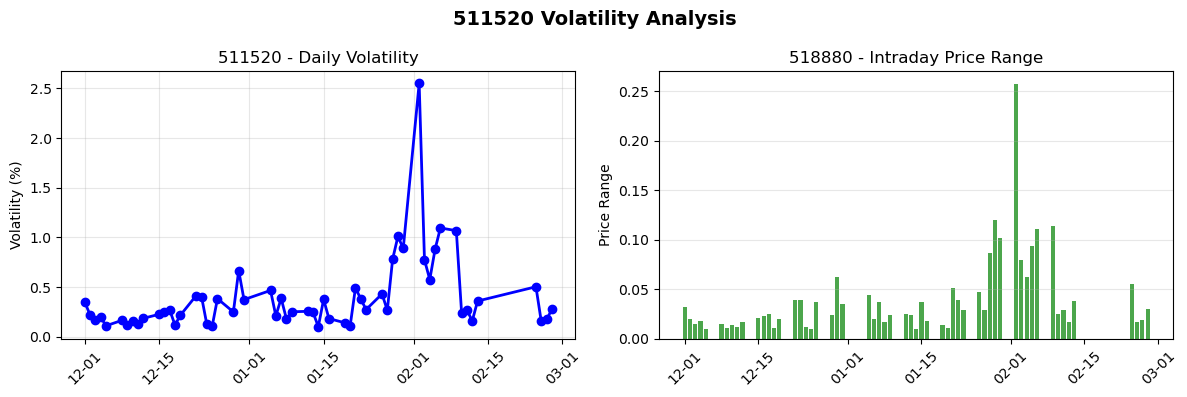

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(df["datetime"], df["range_pct"], "b-o", linewidth=2, markersize=6)
ax1.set_title("511520 - Daily Volatility", fontsize=12)
ax1.set_ylabel("Volatility (%)")
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax1.tick_params(axis="x", rotation=45)

ax2.bar(df["datetime"], df["range"], color="green", alpha=0.7)
ax2.set_title("518880 - Intraday Price Range", fontsize=12)
ax2.set_ylabel("Price Range")
ax2.grid(True, alpha=0.3, axis="y")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax2.tick_params(axis="x", rotation=45)

plt.suptitle("511520 Volatility Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()